# Rank the Files Using a Flat Index
Testing for basic functionality

In [1]:
from index_FlatL2 import IndexFlatL2

In [2]:
# create a new flat index
flat = IndexFlatL2()

In [4]:
# create a faiss index from the stored embeddings
flat.create("100K_embeddings/subset_0", "test_Flat")

Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2963951.661 KB
Time to create index: 29.0262 seconds


In [5]:
# query the results
query = "How to hike the pacific crest trail?"
flat.query(query, k = 3)

Source: 10b7c394d0517b921eee1a211208fefb913406e9.txt
Title: Cultural labor and the defetishization of environments: connecting ethnographies of tourism in Venezuela and Chile
Content: guide, a local Mapuche man, was surprised to find wired fences blocking the forest trail we were following. To facilitate our passing, he had to detach two of the wires from their supporting stakes, reattaching them as soon as we all were on the other side. As we waited for turns to go through, the guide explained that this track was clear the last time he had been there, a couple of months earlier.
Score: 0.3968276083469391
Source: 043648b61661ee5e0200b2421db69d5d684a5cee.txt
Title: 
Content: The same marked routes for Nordic walking and trail running were used for an MTB session, with a lesson on how to use a repair station and how to take advantage of the municipality's surroundings to enjoy different levels of difficulty with bicycles.
Signposting and poster examples from the routes and activities can

In [7]:
query = "How to hike the pacific crest trail?"
query_embedding = flat.embed_text(query)
query_results = flat.query_embedding(query_embedding, k=5)
query_results

{'Content': [{'Source': '10b7c394d0517b921eee1a211208fefb913406e9.txt',
   'Title': 'Title: Cultural labor and the defetishization of environments: connecting ethnographies of tourism in Venezuela and Chile',
   'Content': 'guide, a local Mapuche man, was surprised to find wired fences blocking the forest trail we were following. To facilitate our passing, he had to detach two of the wires from their supporting stakes, reattaching them as soon as we all were on the other side. As we waited for turns to go through, the guide explained that this track was clear the last time he had been there, a couple of months earlier.',
   'Score': 0.3968276},
  {'Source': '043648b61661ee5e0200b2421db69d5d684a5cee.txt',
   'Title': 'Title: ',
   'Content': "The same marked routes for Nordic walking and trail running were used for an MTB session, with a lesson on how to use a repair station and how to take advantage of the municipality's surroundings to enjoy different levels of difficulty with bicycle

# Compare the IVF Flat to the Flat Index

In [8]:
from index_IVFFlat import IndexIVFFlat

In [10]:
ivf_flat = IndexIVFFlat()
# create a faiss index from the stored embeddings
ivf_flat.create("100K_embeddings/subset_0", "test_IVFFlat")

Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2968204.795 KB
Time to create index: 33.0636 seconds


In [12]:
# query the results
query = "How to hike the pacific crest trail?"
ivf_flat.query(query, k = 3)

Source: 0351b5c565cd691ac8176d77d28a23f61138927a.txt
Title: Field Test of a Passive Infrared Camera for Measuring Trail-Based Physical Activity
Content: Data were collected from November 19, 2016 to June 30, 2017 at the main entrance of a hiking trail accessing the West Virginia University (WVU) Falling Run Greenspace/Organic Farm, a 60-acre wooded park in Morgantown, West Virginia, USA (Figure 1 ). This trail is designed for foot traffic only; bicycles are not allowed but were observed occasionally in the present study. Preliminary instrument set up and mounting angle tests were conducted prior to full data collection to ascertain that photos captured bi-directional walking and jogging along the trail concurrently with infrared sensor timestamps. The PIC was cable-locked within a metal security box, mounted to a 10-cm diameter grapevine 3 m from the edge of a 0.6-m wide hiking trail. The camera had an unobstructed view perpendicular to the trail from the uphill slope at roughly 1.8 m 

# Test Evaluating the Accuracy

Create indexes

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from index_FlatL2 import IndexFlatL2
from index_IVFFlat import IndexIVFFlat

In [2]:
flat = IndexFlatL2()
ivf_flat = IndexIVFFlat()

In [3]:
flat.create("100K_embeddings/subset_0", "indexes/flat")
ivf_flat.create("100K_embeddings/subset_0", "indexes/ivf_flat")

Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2963951.661 KB
Time to create index: 25.0649 seconds
Index does not exist
Number of docs in .faiss file: 482414
Number of docs in .pkl file: 482414
File size: 2968204.795 KB
Time to create index: 29.5342 seconds


Create a test set of queries

In [4]:
N_QUERIES = 100
K = 5
test_embeddings = np.load("100K_embeddings/subset_1/embeddings.npy")[:N_QUERIES,:]
# shuffle the dataset
np.random.shuffle(test_embeddings)
# get the test reults
flat_results = []
ivf_flat_results = []
for i in range(N_QUERIES):
    flat_results.append(flat.query_embedding(test_embeddings[i,:][np.newaxis,:], K))
    ivf_flat_results.append(ivf_flat.query_embedding(test_embeddings[i,:][np.newaxis,:], K))

(array([57., 14.,  7.,  4.,  6.,  5.,  1.,  1.,  3.,  2.]),
 array([0.        , 0.02921621, 0.05843241, 0.08764862, 0.11686482,
        0.14608103, 0.17529723, 0.20451345, 0.23372965, 0.26294586,
        0.29216206]),
 <BarContainer object of 10 artists>)

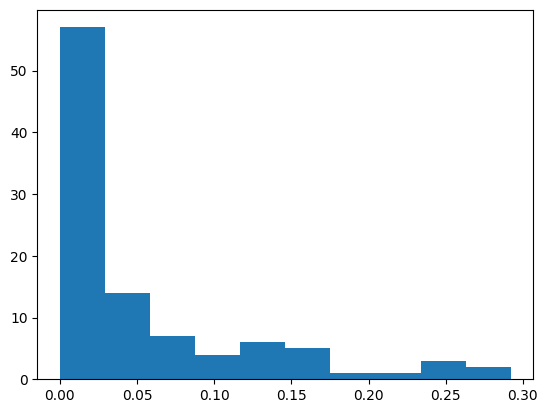

In [17]:
flat_times = [x['Time'] for x in flat_results]
flat_costs = np.array([np.sum([x['Score'] for x in query['Content']]) for query in flat_results])
ivf_flat_times = [x['Time'] for x in ivf_flat_results]
ivf_flat_costs = np.array([np.sum([x['Score'] for x in query['Content']]) for query in ivf_flat_results]) - flat_costs

plt.hist(ivf_flat_costs)